# ****Лабораторная работа №2****: ***Сегментация дорог с Аэрофотоснимков***

## Датасет

In [9]:
from pathlib import Path
from typing import Optional, Callable, List

import numpy as np
import torch
from torch.utils.data import Dataset
import tifffile


class RoadsDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: str = "train",
        image_transform: Optional[Callable] = None,
        mask_transform: Optional[Callable] = None,
        return_paths: bool = False,
        binarize_mask: bool = True,
    ):
        super().__init__()

        self.root = Path(root)
        self.split = split
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.return_paths = return_paths
        self.binarize_mask = binarize_mask

        self.images_dir = self.root / split
        self.masks_dir = self.root / f"{split}_labels"

        image_paths = sorted(self.images_dir.glob("*.tiff"))

        filtered_images: List[Path] = []
        self.mask_map = {}
        for img_path in image_paths:
            mask_path = self.masks_dir / f"{img_path.stem}.tif"
            if mask_path.exists():
                filtered_images.append(img_path)
                self.mask_map[img_path.stem] = mask_path

        self.image_paths = filtered_images

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_map[img_path.stem]

        image = tifffile.imread(str(img_path))
        mask = tifffile.imread(str(mask_path))

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.float32)

        # Важно: для сегментации случайные аугментации должны быть одинаковыми для image и mask
        if self.image_transform is not None and self.mask_transform is not None:
            seed = torch.randint(0, 2**31 - 1, (1,)).item()
            torch.manual_seed(seed)
            image = self.image_transform(image)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)
        else:
            if self.image_transform is not None:
                image = self.image_transform(image)
            if self.mask_transform is not None:
                mask = self.mask_transform(mask)

        if isinstance(mask, torch.Tensor):
            mask = (mask > 0.5).float()

        if self.return_paths:
            return image, mask, str(img_path)

        return image, mask

In [10]:
import torchvision.transforms as T

CROP_SIZE = (600, 600)

# train: ToTensor + crop + аугментации
train_image_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(CROP_SIZE, pad_if_needed=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

train_mask_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(CROP_SIZE, pad_if_needed=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

# val/test: ToTensor + crop
val_image_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(CROP_SIZE),
])
val_mask_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(CROP_SIZE),
])

test_image_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(CROP_SIZE),
])
test_mask_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(CROP_SIZE),
])

# Пример создания датасетов:
train_ds = RoadsDataset(
    root="roads_dataset/tiff",
    split="train",
    image_transform=train_image_transform,
    mask_transform=train_mask_transform,
)

val_ds = RoadsDataset(
    root="roads_dataset/tiff",
    split="val",
    image_transform=val_image_transform,
    mask_transform=val_mask_transform,
)

test_ds = RoadsDataset(
    root="roads_dataset/tiff",
    split="test",
    image_transform=test_image_transform,
    mask_transform=test_mask_transform,
)

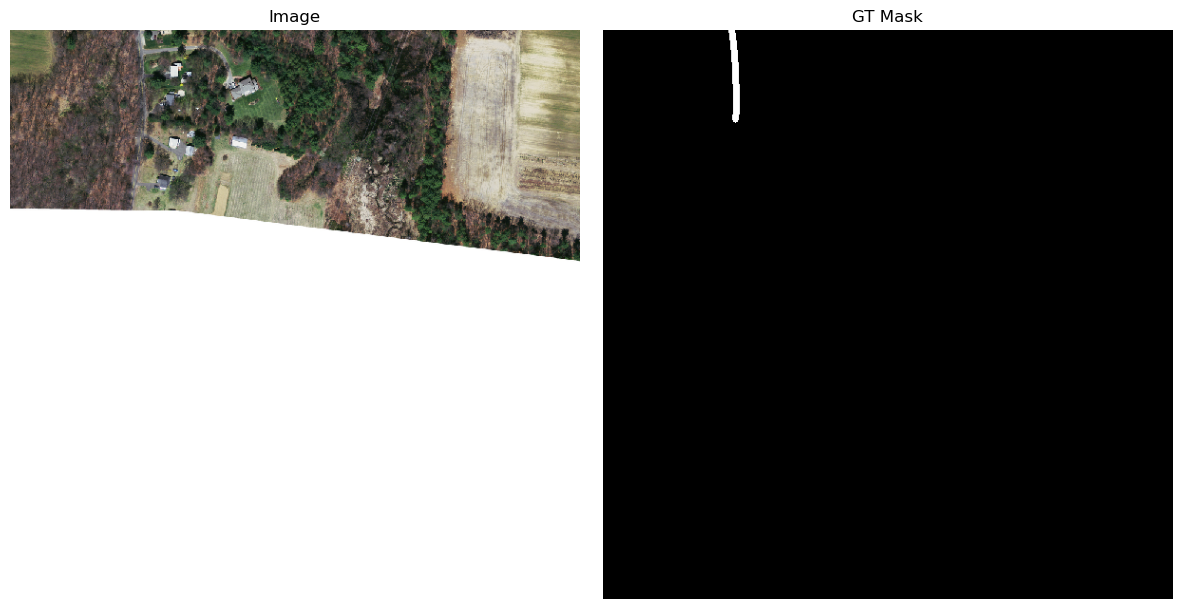

Image shape: torch.Size([3, 600, 600])
Mask shape: torch.Size([1, 600, 600])


In [11]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

image, mask = train_ds[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))